# Chapter 35: 3-Forms

## Source Span And Goal

This notebook covers printed pages 386-391, PDF pages 415-420, of *Visual Differential Geometry and Forms*. I extracted that span before editing and used it only for orientation: terminology, sequence of ideas, and checks. The prose, code, diagrams, tables, and artifacts below are original standalone teaching material.

**Chapter goal.** A 3-form is an oriented volume meter. By the end of this notebook, the algebraic rules for wedge products should feel like operating instructions for that meter: repeat a direction and the volume collapses, swap two slots and the sign flips, change coordinates and the pullback contributes a determinant.

## Computational Translation Guide

| Chapter idea | Computational object in this notebook | What to inspect |
| --- | --- | --- |
| A 3-form needs three independent directions | determinant and an alternating-form dimension lock | repeated columns force zero volume |
| A 2-form wedged with a 1-form makes a 3-form | cyclic formula for `(dx wedge dy) wedge dz` | the three cyclic terms sum to the same determinant |
| The volume 3-form | `dx wedge dy wedge dz` evaluated on three edge vectors | sign and magnitude of an oriented parallelepiped |
| Spherical polar volume | symbolic pullback of `dx wedge dy wedge dz` | the factor `r**2 sin(phi)` |
| Three 1-forms wedged together | determinant of the matrix of form evaluations | the six signed tensor terms |
| Basis 3-forms | combination ledger for `C(n, 3)` basis triples | no basis triples exist in `R^2`; four exist in `R^4` |
| Can a form wedge nontrivially with itself? | exterior-algebra dictionary checks | odd degree self-wedges vanish; an even 2-form can square to a 4-form |

## Refreshed Visual Storyboard

The improvement pass implements this concept sequence under `artifacts/chapter-35/`:

1. `oriented-volume-box-determinant.png` and `oriented-volume-box-determinant.html`: a signed volume box and the same box after swapping two input slots.
2. `repeated-direction-vanishing-proof.png`: a proof-state graph showing why an alternating 3-form gives zero when two directions repeat, and why that locks 3-forms out of `R^2`.
3. `wedge-product-determinant-ledger.png` and `.csv`: the six signed determinant terms and the cyclic `(2-form) wedge (1-form)` terms on the same numerical example.
4. `spherical-volume-jacobian.png` and `spherical-volume-pullback-density.html`: a local spherical coordinate box and the pullback density `r**2 sin(phi)`.
5. `basis-3-form-ledger.png` plus CSV ledgers: basis triples by dimension and the cyclic four-term ledger for `R^4`.
6. `graded-commutativity-swap-ledger.png`: the sign produced by moving a `p`-form past a `q`-form.
7. `three-form-orientation-lab.png`: a small calibration lab for a volume meter under swaps, repeated slots, and a linear coordinate change.

The artifacts are not page crops or textbook figures. Each one is generated from executable geometry in this notebook and checked at the end.

In [1]:
from __future__ import annotations

import itertools
import json
import math
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import sympy as sp
import networkx as nx

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from PIL import Image
import plotly.graph_objects as go

BOOK_ROOT = Path.cwd()
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the Visual Differential Geometry and Forms book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import artifact_path, display_artifact, save_json, save_matplotlib, save_plotly_html

ARTIFACT_TOPIC = "chapter-35"
ARTIFACT_BASE = BOOK_ROOT / "artifacts"

np.set_printoptions(precision=5, suppress=True)

artifact_records: dict[str, dict[str, object]] = {}
check_records: dict[str, str] = {}
table_records: dict[str, str] = {}
validation_data: dict[str, object] = {}


def rel(path: str | Path) -> str:
    return Path(path).relative_to(BOOK_ROOT).as_posix()


def artifact_metrics(path: str | Path) -> dict[str, object]:
    path = Path(path)
    metrics: dict[str, object] = {"file_size": path.stat().st_size}
    if path.suffix.lower() in {".png", ".jpg", ".jpeg", ".webp"}:
        image = Image.open(path).convert("L")
        arr = np.asarray(image, dtype=float)
        metrics.update(
            {
                "width": image.width,
                "height": image.height,
                "pixel_mean": float(arr.mean()),
                "pixel_std": float(arr.std()),
            }
        )
    return metrics


def record_artifact(path: str | Path, *, concept: str, kind: str, inspection_target: str) -> Path:
    path = Path(path)
    artifact_records[rel(path)] = {
        "relative_path": rel(path),
        "concept": concept,
        "kind": kind,
        "inspection_target": inspection_target,
        "metrics": artifact_metrics(path),
    }
    return path


def save_check(data: object, filename: str) -> Path:
    path = save_json(data, ARTIFACT_TOPIC, "checks", filename, root=ARTIFACT_BASE)
    check_records[rel(path)] = filename
    return path


def record_table(path: str | Path, name: str) -> Path:
    path = Path(path)
    table_records[rel(path)] = name
    return path


def save_figure(fig: plt.Figure, filename: str, *, concept: str, kind: str, inspection_target: str, dpi: int = 170) -> Path:
    path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", filename, root=ARTIFACT_BASE, dpi=dpi)
    plt.close(fig)
    return record_artifact(path, concept=concept, kind=kind, inspection_target=inspection_target)


def set_axes_equal(ax) -> None:
    limits = np.array([ax.get_xlim3d(), ax.get_ylim3d(), ax.get_zlim3d()], dtype=float)
    centers = limits.mean(axis=1)
    radius = 0.5 * np.max(limits[:, 1] - limits[:, 0])
    ax.set_xlim3d([centers[0] - radius, centers[0] + radius])
    ax.set_ylim3d([centers[1] - radius, centers[1] + radius])
    ax.set_zlim3d([centers[2] - radius, centers[2] + radius])


print(f"Book root: {BOOK_ROOT.relative_to(BOOK_ROOT.parent).as_posix()}")

Book root: Visual-Differential-Geometry-and-Forms


## Source-Specific Storyboard And Library Routing

The visual plan is saved as JSON so the chapter can be audited without opening the notebook. The library choices follow the geometry: Plotly is used where rotating a 3D volume box helps, Matplotlib is used for durable static proof and ledger artifacts, SymPy checks the coordinate pullback exactly, NetworkX shows the proof dependency state, and pandas keeps the basis ledgers inspectable.

In [2]:
source_span = {
    "label": "Chapter 35",
    "title": "3-Forms",
    "printed_pages": "386-391",
    "pdf_pages": "415-420",
    "source_pdf": "Visual Differential Geometry and Forms.pdf",
    "source_words_read_by_pdftotext": 2630,
    "source_use_note": "Source span extracted for orientation only; no source prose, exercise text, figures, page crops, or screenshots are copied.",
    "topics": [
        "3-forms require at least three dimensions",
        "wedge product of a 2-form and a 1-form",
        "volume 3-form as dx1 wedge dx2 wedge dx3",
        "spherical polar coordinate volume form",
        "wedge product of three and p one-forms",
        "basis 3-forms in R3, R4, and higher dimensions",
        "odd self-wedges vanish, while even self-wedges can be nonzero",
    ],
}

storyboard = {
    "chapter_goal": "Understand a 3-form as an oriented volume meter whose signs and zeros are forced by alternation.",
    "source_span_read": {
        "printed_pages": source_span["printed_pages"],
        "pdf_pages": source_span["pdf_pages"],
        "source_pdf": source_span["source_pdf"],
        "pdftotext_word_count": source_span["source_words_read_by_pdftotext"],
        "notes": source_span["source_use_note"],
    },
    "concept_inventory": [
        "Alternating 3-slots force repeated directions to vanish.",
        "The volume 3-form evaluates to the determinant of edge coordinates.",
        "The wedge of a 2-form and a 1-form is graded-commutative with sign (-1)^(2*1)=+1.",
        "The wedge of three 1-forms is the determinant of their evaluation matrix.",
        "The pullback of dx wedge dy wedge dz under spherical coordinates is the Jacobian determinant times dr wedge dphi wedge dtheta.",
        "Basis 3-forms are indexed by distinct triples; there are binomial(n,3) of them in n dimensions.",
        "Odd-degree forms wedge with themselves to zero, but even-degree forms need not.",
    ],
    "library_routing_table": [
        {
            "concept": "oriented volume box",
            "representation": "rotatable parallelepiped plus static sign comparison",
            "library": "Plotly and Matplotlib",
            "why": "a 3-form is spatial and orientation is clearer when the box can be rotated; static PNG keeps the artifact durable",
            "fallback": "Matplotlib 3D PNG only",
        },
        {
            "concept": "repeated direction vanishes",
            "representation": "proof dependency graph",
            "library": "NetworkX with Matplotlib",
            "why": "the proof is a state transition from alternation plus equality of slots to zero",
            "fallback": "Matplotlib text diagram",
        },
        {
            "concept": "wedge determinant expansion",
            "representation": "signed ledger table and cyclic term chart",
            "library": "pandas and Matplotlib",
            "why": "the learner needs to inspect each signed term, not just the final determinant",
            "fallback": "plain markdown table generated from Python lists",
        },
        {
            "concept": "spherical volume pullback",
            "representation": "symbolic Jacobian, local coordinate edge box, and density surface",
            "library": "SymPy, Matplotlib, Plotly",
            "why": "the exact determinant and geometric edge lengths are both central",
            "fallback": "SymPy text check plus Matplotlib static figure",
        },
        {
            "concept": "basis 3-form ledger and graded signs",
            "representation": "dimension-count table and sign heatmap",
            "library": "pandas and Matplotlib",
            "why": "basis availability and sign parity are combinatorial ledgers",
            "fallback": "JSON ledgers only",
        },
    ],
    "visual_sequence": [
        {
            "concept": "oriented volume box determinant",
            "artifacts": ["figures/oriented-volume-box-determinant.png", "html/oriented-volume-box-determinant.html"],
            "learner_inspection_target": "Swapping two input slots reverses the sign but not the absolute volume.",
            "validation": "det(u,v,w) + det(v,u,w) = 0 and det(u,u,w) = 0",
        },
        {
            "concept": "repeated direction vanishing proof",
            "artifact": "figures/repeated-direction-vanishing-proof.png",
            "learner_inspection_target": "The same input equals its negative after swapping equal slots, so the output is zero.",
            "validation": "every ordered triple in a two-element basis repeats an index",
        },
        {
            "concept": "wedge product determinant ledger",
            "artifacts": ["figures/wedge-product-determinant-ledger.png", "tables/wedge-product-determinant-ledger.csv"],
            "learner_inspection_target": "The six signed tensor terms and the three cyclic 2-form terms give the same determinant.",
            "validation": "six-term sum equals determinant and cyclic formula equals determinant",
        },
        {
            "concept": "spherical volume Jacobian and pullback density",
            "artifacts": ["figures/spherical-volume-jacobian.png", "html/spherical-volume-pullback-density.html"],
            "learner_inspection_target": "A coordinate box with edges dr, r dphi, r sin(phi) dtheta has volume density r**2 sin(phi).",
            "validation": "SymPy determinant simplifies to r**2*sin(phi)",
        },
        {
            "concept": "basis 3-form ledger",
            "artifacts": ["figures/basis-3-form-ledger.png", "tables/basis-3-form-ledger.csv", "tables/r4-cyclic-basis-3form-ledger.csv"],
            "learner_inspection_target": "Basis 3-forms are distinct triples, so C(2,3)=0, C(3,3)=1, and C(4,3)=4.",
            "validation": "basis counts equal binomial(n,3)",
        },
        {
            "concept": "graded commutativity swap ledger",
            "artifact": "figures/graded-commutativity-swap-ledger.png",
            "learner_inspection_target": "Moving p one-forms past q one-forms performs p*q swaps.",
            "validation": "sign matrix equals (-1)^(p*q), odd self-sign is -1",
        },
        {
            "concept": "orientation lab",
            "artifact": "figures/three-form-orientation-lab.png",
            "learner_inspection_target": "A calibrated volume meter catches slot swaps, repeated slots, and coordinate determinant scaling.",
            "validation": "sample volumes flip sign under swap and scale by det(A) under a linear map",
        },
    ],
    "artifact_plan": {
        "root": "artifacts/chapter-35",
        "figures": "PNG concept diagrams and ledgers",
        "html": "Plotly rotatable box and pullback density",
        "tables": "CSV determinant and basis ledgers",
        "checks": "JSON source span, storyboard, symbolic/numeric checks, and final sanity",
    },
    "computational_checks": [
        "alternating determinant changes sign under slot swap",
        "repeated direction evaluates to zero",
        "2-form wedge 1-form cyclic formula equals the determinant",
        "three 1-form wedge expansion equals the six-term determinant",
        "spherical coordinate pullback determinant is r**2*sin(phi)",
        "basis 3-form counts are binomial(n, 3)",
        "odd self-wedge is zero and the spacetime 2-form example squares to 2 times the 4-volume form",
        "all concept-named artifacts exist and have nonzero size",
    ],
    "proof_visualization_strategy": "Use a NetworkX proof-state graph for repeated directions and a swap-count ledger for graded commutativity; both expose the sign changes as visible proof states.",
    "implementation_notes": "All helpers are notebook-local. Only the assigned notebook and artifacts/chapter-35 are written.",
    "risks": [
        "Plotly HTML display depends on browser support, so static PNG companions are also generated.",
        "Matplotlib 3D is not a full CAD model; determinant and edge-length checks carry the numerical validation.",
    ],
    "acceptance_criteria": [
        "Notebook executes with nbclient from the chapter directory.",
        "visual-storyboard.json contains chapter-specific concepts and library routing.",
        "three-form-volume-checks.json and final-sanity.json contain only chapter-relevant assertions.",
        "Artifacts are concept-named and stored under artifacts/chapter-35.",
    ],
}

source_path = save_check(source_span, "source-span.json")
storyboard_path = save_check(storyboard, "visual-storyboard.json")

assert source_path.exists()
assert storyboard_path.exists()
assert any("spherical" in item["concept"] for item in storyboard["visual_sequence"])
print(rel(source_path))
print(rel(storyboard_path))

artifacts/chapter-35/checks/source-span.json
artifacts/chapter-35/checks/visual-storyboard.json


## Exterior Algebra Micro-Toolkit

The notebook uses a small dictionary model for basis forms. A key such as `("x", "y", "z")` represents `dx wedge dy wedge dz`; the coefficient is the scalar multiplying that basis blade. The only algebraic rule built into `wedge_forms` is alternation: if a basis direction repeats, the product is zero; otherwise the directions are sorted into the chosen orientation order and the parity of the sorting permutation supplies the sign.

This is intentionally small. It is enough to test the chapter's sign claims without hiding the geometry inside a symbolic exterior-algebra package.

In [3]:
def canonical_blade(indices: tuple[str, ...], order: tuple[str, ...]) -> tuple[tuple[str, ...] | None, int]:
    if len(set(indices)) != len(indices):
        return None, 0
    position = {label: index for index, label in enumerate(order)}
    ranks = [position[label] for label in indices]
    inversions = sum(1 for i in range(len(ranks)) for j in range(i + 1, len(ranks)) if ranks[i] > ranks[j])
    blade = tuple(sorted(indices, key=position.__getitem__))
    sign = -1 if inversions % 2 else 1
    return blade, sign


def wedge_forms(a: dict[tuple[str, ...], float], b: dict[tuple[str, ...], float], order: tuple[str, ...]) -> dict[tuple[str, ...], float]:
    out: dict[tuple[str, ...], float] = {}
    for blade_a, coeff_a in a.items():
        for blade_b, coeff_b in b.items():
            blade, sign = canonical_blade(blade_a + blade_b, order)
            if blade is None:
                continue
            out[blade] = out.get(blade, 0.0) + coeff_a * coeff_b * sign
    return {blade: coeff for blade, coeff in out.items() if abs(coeff) > 1e-12}


def basis_form(*labels: str, coeff: float = 1.0, order: tuple[str, ...]) -> dict[tuple[str, ...], float]:
    blade, sign = canonical_blade(tuple(labels), order)
    if blade is None:
        return {}
    return {blade: coeff * sign}


def add_forms(*forms: dict[tuple[str, ...], float]) -> dict[tuple[str, ...], float]:
    out: dict[tuple[str, ...], float] = {}
    for form in forms:
        for blade, coeff in form.items():
            out[blade] = out.get(blade, 0.0) + coeff
    return {blade: coeff for blade, coeff in out.items() if abs(coeff) > 1e-12}


def form_to_strings(form: dict[tuple[str, ...], float]) -> dict[str, float]:
    return {"^".join(blade): float(coeff) for blade, coeff in sorted(form.items())}


order3 = ("x", "y", "z")
order4 = ("t", "x", "y", "z")
order6 = ("x", "y", "z", "a", "b", "c")

volume3 = basis_form("x", "y", "z", order=order3)
repeated_3form = wedge_forms(basis_form("x", "y", order=order3), basis_form("x", order=order3), order3)
odd_self = wedge_forms(volume3, volume3, order6)
psi = add_forms(basis_form("t", "x", order=order4), basis_form("y", "z", order=order4))
psi_square = wedge_forms(psi, psi, order4)

algebra_checks = {
    "volume3": form_to_strings(volume3),
    "dx_wedge_dy_wedge_dx": form_to_strings(repeated_3form),
    "odd_three_form_self_wedge": form_to_strings(odd_self),
    "spacetime_two_form": form_to_strings(psi),
    "spacetime_two_form_square": form_to_strings(psi_square),
    "dimension_two_basis_3form_count": math.comb(2, 3) if 2 >= 3 else 0,
    "dimension_four_basis_3form_count": math.comb(4, 3),
}

assert repeated_3form == {}
assert odd_self == {}
assert psi_square == {("t", "x", "y", "z"): 2.0}
assert algebra_checks["dimension_two_basis_3form_count"] == 0
assert algebra_checks["dimension_four_basis_3form_count"] == 4

algebra_path = save_check(algebra_checks, "core-exterior-algebra-checks.json")
validation_data["exterior_algebra"] = algebra_checks
print(rel(algebra_path))
print(json.dumps(algebra_checks, indent=2, sort_keys=True))

artifacts/chapter-35/checks/core-exterior-algebra-checks.json
{
  "dimension_four_basis_3form_count": 4,
  "dimension_two_basis_3form_count": 0,
  "dx_wedge_dy_wedge_dx": {},
  "odd_three_form_self_wedge": {},
  "spacetime_two_form": {
    "t^x": 1.0,
    "y^z": 1.0
  },
  "spacetime_two_form_square": {
    "t^x^y^z": 2.0
  },
  "volume3": {
    "x^y^z": 1.0
  }
}


## Oriented Volume Boxes

A 3-form eats three directed edge vectors. For the coordinate volume form `dx wedge dy wedge dz`, the output is the determinant with those edge vectors as columns. The sign is not a secondary convention; it is part of the measurement. Swapping two input slots reverses orientation, while repeating a slot collapses the three-dimensional box.

The static artifact compares a box with slot order `(u, v, w)` against the same edges with the first two slots swapped. The HTML artifact lets you rotate the positive box and inspect the three edge directions.

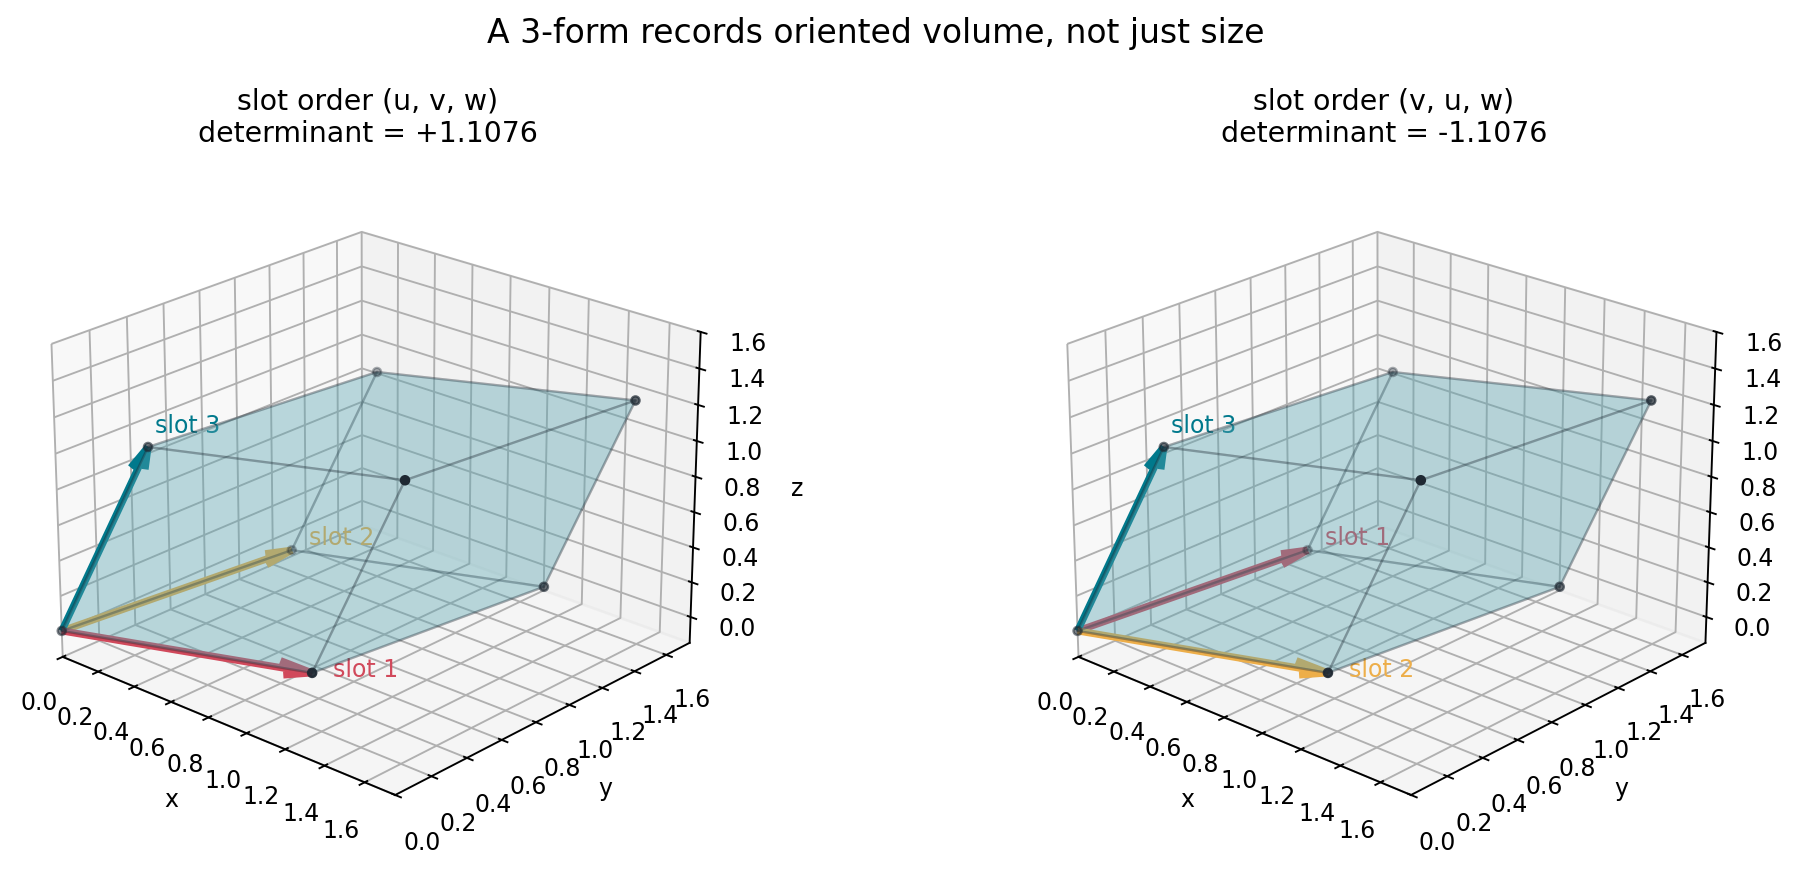

artifacts/chapter-35/checks/oriented-volume-box-checks.json


In [4]:
u = np.array([1.20, 0.15, 0.20])
v = np.array([0.25, 1.05, 0.10])
w = np.array([0.15, 0.35, 0.95])
edge_matrix = np.column_stack([u, v, w])
volume_det = float(np.linalg.det(edge_matrix))
swapped_det = float(np.linalg.det(np.column_stack([v, u, w])))
repeated_det = float(np.linalg.det(np.column_stack([u, u, w])))

vertices = np.array([[0, 0, 0], u, v, w, u + v, u + w, v + w, u + v + w])
faces = [
    [0, 1, 4, 2], [0, 1, 5, 3], [0, 2, 6, 3],
    [7, 4, 1, 5], [7, 4, 2, 6], [7, 5, 3, 6],
]

fig = plt.figure(figsize=(12.5, 5.2))
for panel, (a, b, c, title, det_value) in enumerate(
    [(u, v, w, "slot order (u, v, w)", volume_det), (v, u, w, "slot order (v, u, w)", swapped_det)],
    start=1,
):
    ax = fig.add_subplot(1, 2, panel, projection="3d")
    panel_vertices = np.array([[0, 0, 0], a, b, c, a + b, a + c, b + c, a + b + c])
    poly = Poly3DCollection(panel_vertices[faces], alpha=0.22, facecolor="#58a4b0", edgecolor="#1f2933", linewidth=1.0)
    ax.add_collection3d(poly)
    colors = ["#d1495b", "#edae49", "#00798c"]
    labels = ["slot 1", "slot 2", "slot 3"]
    for vec, color, label in zip([a, b, c], colors, labels):
        ax.quiver(0, 0, 0, vec[0], vec[1], vec[2], color=color, linewidth=3, arrow_length_ratio=0.12)
        ax.text(*(1.08 * vec), label, color=color, fontsize=10)
    ax.scatter(*panel_vertices.T, color="#1f2933", s=12)
    ax.set_title(f"{title}\ndeterminant = {det_value:+.4f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_xlim(0, 1.75)
    ax.set_ylim(0, 1.75)
    ax.set_zlim(0, 1.45)
    set_axes_equal(ax)
    ax.view_init(elev=23, azim=-48)
fig.suptitle("A 3-form records oriented volume, not just size", fontsize=14, y=0.98)
fig.tight_layout()
volume_png = save_figure(
    fig,
    "oriented-volume-box-determinant.png",
    concept="oriented volume box determinant",
    kind="figure",
    inspection_target="Swapping two input slots reverses the determinant sign while preserving the same geometric edges.",
)

i, j, k = [], [], []
for face in faces:
    i.extend([face[0], face[0]])
    j.extend([face[1], face[2]])
    k.extend([face[2], face[3]])

mesh = go.Mesh3d(
    x=vertices[:, 0], y=vertices[:, 1], z=vertices[:, 2],
    i=i, j=j, k=k,
    color="#58a4b0", opacity=0.35, name="oriented volume box",
)
edge_traces = []
for start, end in [(0, 1), (0, 2), (0, 3), (1, 4), (1, 5), (2, 4), (2, 6), (3, 5), (3, 6), (4, 7), (5, 7), (6, 7)]:
    edge_traces.append(
        go.Scatter3d(
            x=[vertices[start, 0], vertices[end, 0]],
            y=[vertices[start, 1], vertices[end, 1]],
            z=[vertices[start, 2], vertices[end, 2]],
            mode="lines", line=dict(color="#1f2933", width=4), showlegend=False,
        )
    )
cone = go.Cone(
    x=[0, 0, 0], y=[0, 0, 0], z=[0, 0, 0],
    u=[u[0], v[0], w[0]], v=[u[1], v[1], w[1]], w=[u[2], v[2], w[2]],
    sizemode="absolute", sizeref=0.45, anchor="tail",
    colorscale=[[0, "#d1495b"], [0.5, "#edae49"], [1, "#00798c"]],
    showscale=False, name="input slots",
)
plotly_fig = go.Figure(data=[mesh, *edge_traces, cone])
plotly_fig.update_layout(
    title=f"dx wedge dy wedge dz on three edge vectors: determinant {volume_det:+.4f}",
    scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="z", aspectmode="data"),
    margin=dict(l=0, r=0, t=55, b=0),
)
volume_html = save_plotly_html(plotly_fig, ARTIFACT_TOPIC, "html", "oriented-volume-box-determinant.html", root=ARTIFACT_BASE)
record_artifact(
    volume_html,
    concept="interactive oriented volume box determinant",
    kind="html",
    inspection_target="Rotate the parallelepiped and track the three ordered input slots that set the orientation sign.",
)

volume_checks = {
    "det_u_v_w": volume_det,
    "det_v_u_w": swapped_det,
    "det_u_u_w": repeated_det,
    "swap_reverses_sign": abs(volume_det + swapped_det) < 1e-12,
    "repeated_direction_zero": abs(repeated_det) < 1e-12,
}
assert volume_checks["det_u_v_w"] > 0
assert volume_checks["swap_reverses_sign"]
assert volume_checks["repeated_direction_zero"]
volume_check_path = save_check(volume_checks, "oriented-volume-box-checks.json")
validation_data["oriented_volume_box"] = volume_checks

display_artifact(volume_png, width=760)
display_artifact(volume_html, width="100%", height=500)
print(rel(volume_check_path))

## Why Repeated Directions Vanish

Alternation says that swapping two input slots multiplies the value by `-1`. If the two swapped slots contain the same vector, the ordered input has not changed at all. The only scalar equal to its own negative is zero. This is the proof state behind the dimension lock: in a two-dimensional basis, any ordered triple of basis directions repeats one of the two directions, so every component of a 3-form vanishes.

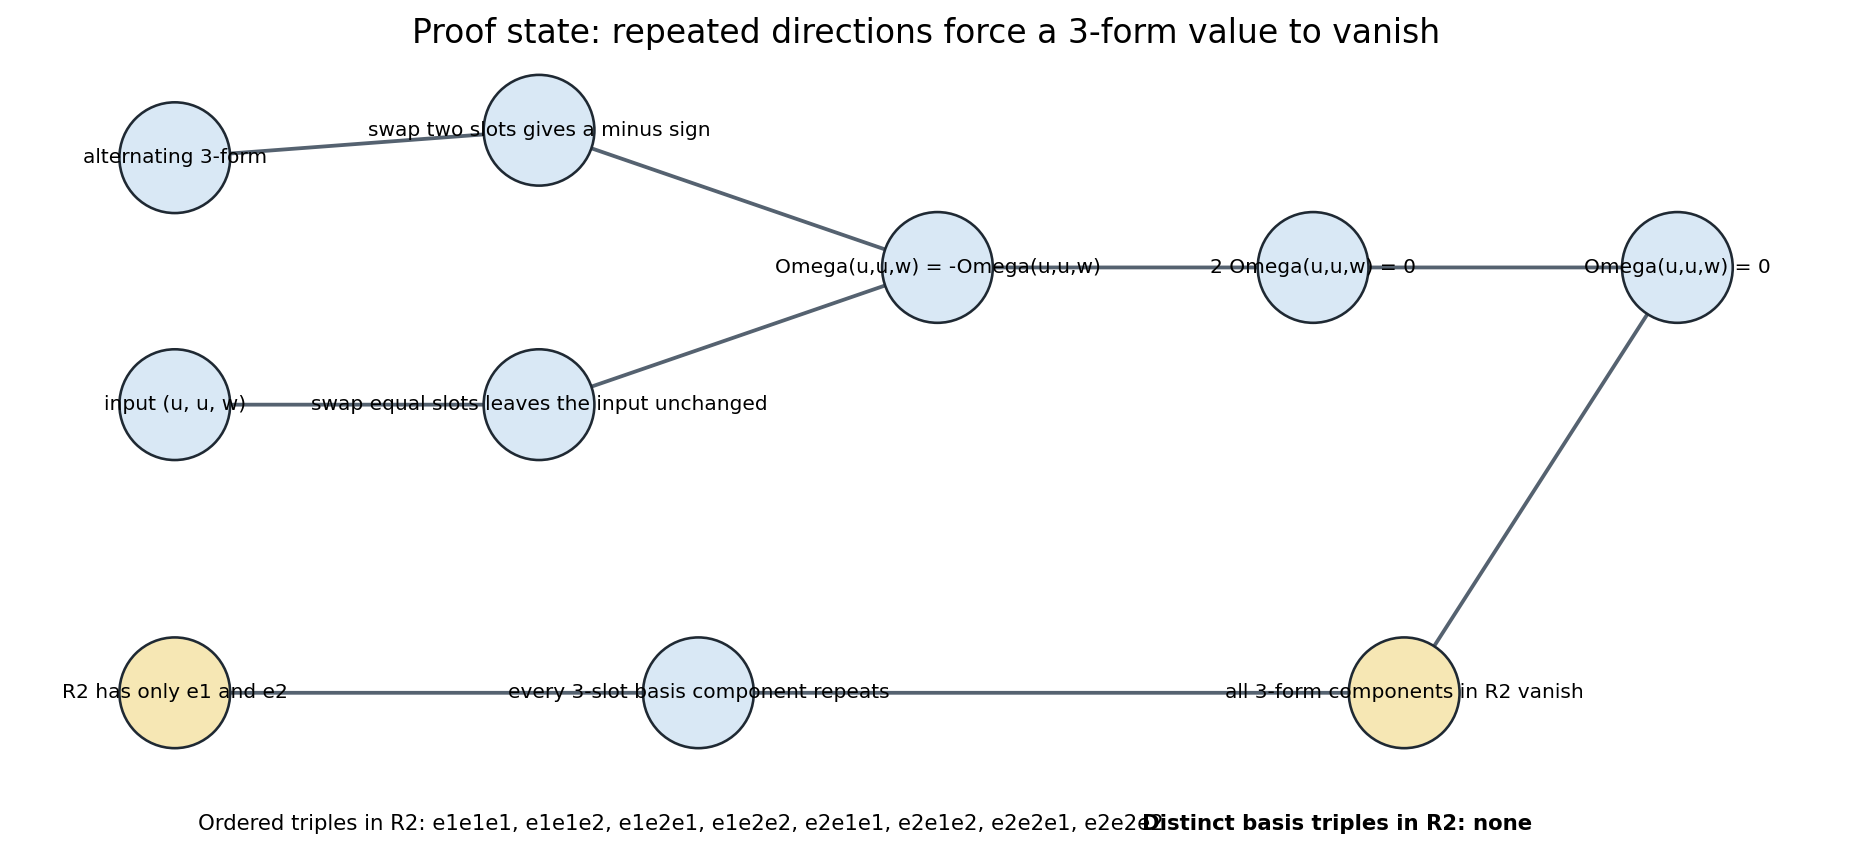

artifacts/chapter-35/checks/dimension-lock-checks.json


In [5]:
triples_in_r2 = list(itertools.product(["e1", "e2"], repeat=3))
all_r2_triples_repeat = all(len(set(triple)) < 3 for triple in triples_in_r2)
basis_triples_by_dimension = {n: list(itertools.combinations(range(1, n + 1), 3)) for n in range(2, 6)}

G = nx.DiGraph()
G.add_edges_from(
    [
        ("alternating 3-form", "swap two slots gives a minus sign"),
        ("input (u, u, w)", "swap equal slots leaves the input unchanged"),
        ("swap two slots gives a minus sign", "Omega(u,u,w) = -Omega(u,u,w)"),
        ("swap equal slots leaves the input unchanged", "Omega(u,u,w) = -Omega(u,u,w)"),
        ("Omega(u,u,w) = -Omega(u,u,w)", "2 Omega(u,u,w) = 0"),
        ("2 Omega(u,u,w) = 0", "Omega(u,u,w) = 0"),
        ("R2 has only e1 and e2", "every 3-slot basis component repeats"),
        ("every 3-slot basis component repeats", "all 3-form components in R2 vanish"),
        ("Omega(u,u,w) = 0", "all 3-form components in R2 vanish"),
    ]
)
pos = {
    "alternating 3-form": (0.0, 2.0),
    "swap two slots gives a minus sign": (1.6, 2.1),
    "input (u, u, w)": (0.0, 1.1),
    "swap equal slots leaves the input unchanged": (1.6, 1.1),
    "Omega(u,u,w) = -Omega(u,u,w)": (3.35, 1.6),
    "2 Omega(u,u,w) = 0": (5.0, 1.6),
    "Omega(u,u,w) = 0": (6.6, 1.6),
    "R2 has only e1 and e2": (0.0, 0.05),
    "every 3-slot basis component repeats": (2.3, 0.05),
    "all 3-form components in R2 vanish": (5.4, 0.05),
}

fig, ax = plt.subplots(figsize=(13.8, 5.2))
ax.set_title("Proof state: repeated directions force a 3-form value to vanish", fontsize=14, pad=12)
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=14, width=1.6, edge_color="#556270")
node_colors = ["#d9e8f5" if "R2" not in node and "components" not in node else "#f6e7b4" for node in G.nodes]
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, edgecolors="#1f2933", node_size=2200, linewidths=1.1)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8.5)
ax.text(0.1, -0.45, "Ordered triples in R2: " + ", ".join("".join(t) for t in triples_in_r2), fontsize=9)
ax.text(4.25, -0.45, "Distinct basis triples in R2: none", fontsize=9, fontweight="bold")
ax.axis("off")
proof_png = save_figure(
    fig,
    "repeated-direction-vanishing-proof.png",
    concept="repeated direction vanishing proof",
    kind="proof graph",
    inspection_target="Follow the two proof inputs: equal slots leave the input fixed, alternation changes the sign, so the value is zero.",
)

dimension_lock_checks = {
    "ordered_basis_triples_in_R2": ["".join(triple) for triple in triples_in_r2],
    "all_R2_ordered_triples_repeat": all_r2_triples_repeat,
    "basis_3form_counts_by_dimension": {str(n): len(triples) for n, triples in basis_triples_by_dimension.items()},
    "R2_has_no_basis_3forms": len(basis_triples_by_dimension[2]) == 0,
    "R3_has_one_basis_3form": len(basis_triples_by_dimension[3]) == 1,
    "R4_has_four_basis_3forms": len(basis_triples_by_dimension[4]) == 4,
}
assert dimension_lock_checks["all_R2_ordered_triples_repeat"]
assert dimension_lock_checks["R2_has_no_basis_3forms"]
assert dimension_lock_checks["R4_has_four_basis_3forms"]
dimension_check_path = save_check(dimension_lock_checks, "dimension-lock-checks.json")
validation_data["dimension_lock"] = dimension_lock_checks

display_artifact(proof_png, width=820)
print(rel(dimension_check_path))

## The Wedge Product As A Determinant Ledger

For three 1-forms `sigma_1, sigma_2, sigma_3`, the wedge `sigma_1 wedge sigma_2 wedge sigma_3` evaluates on vectors `v_1, v_2, v_3` as the determinant of the matrix whose `(i,j)` entry is `sigma_i(v_j)`. That determinant has six signed terms.

The same volume form can be built as `(dx wedge dy) wedge dz`. Its cyclic formula has only three terms because the 2-form part has already combined pairs of slots. The two ledgers below use the same vectors as the volume-box artifact, so the final number must match the determinant already checked above.

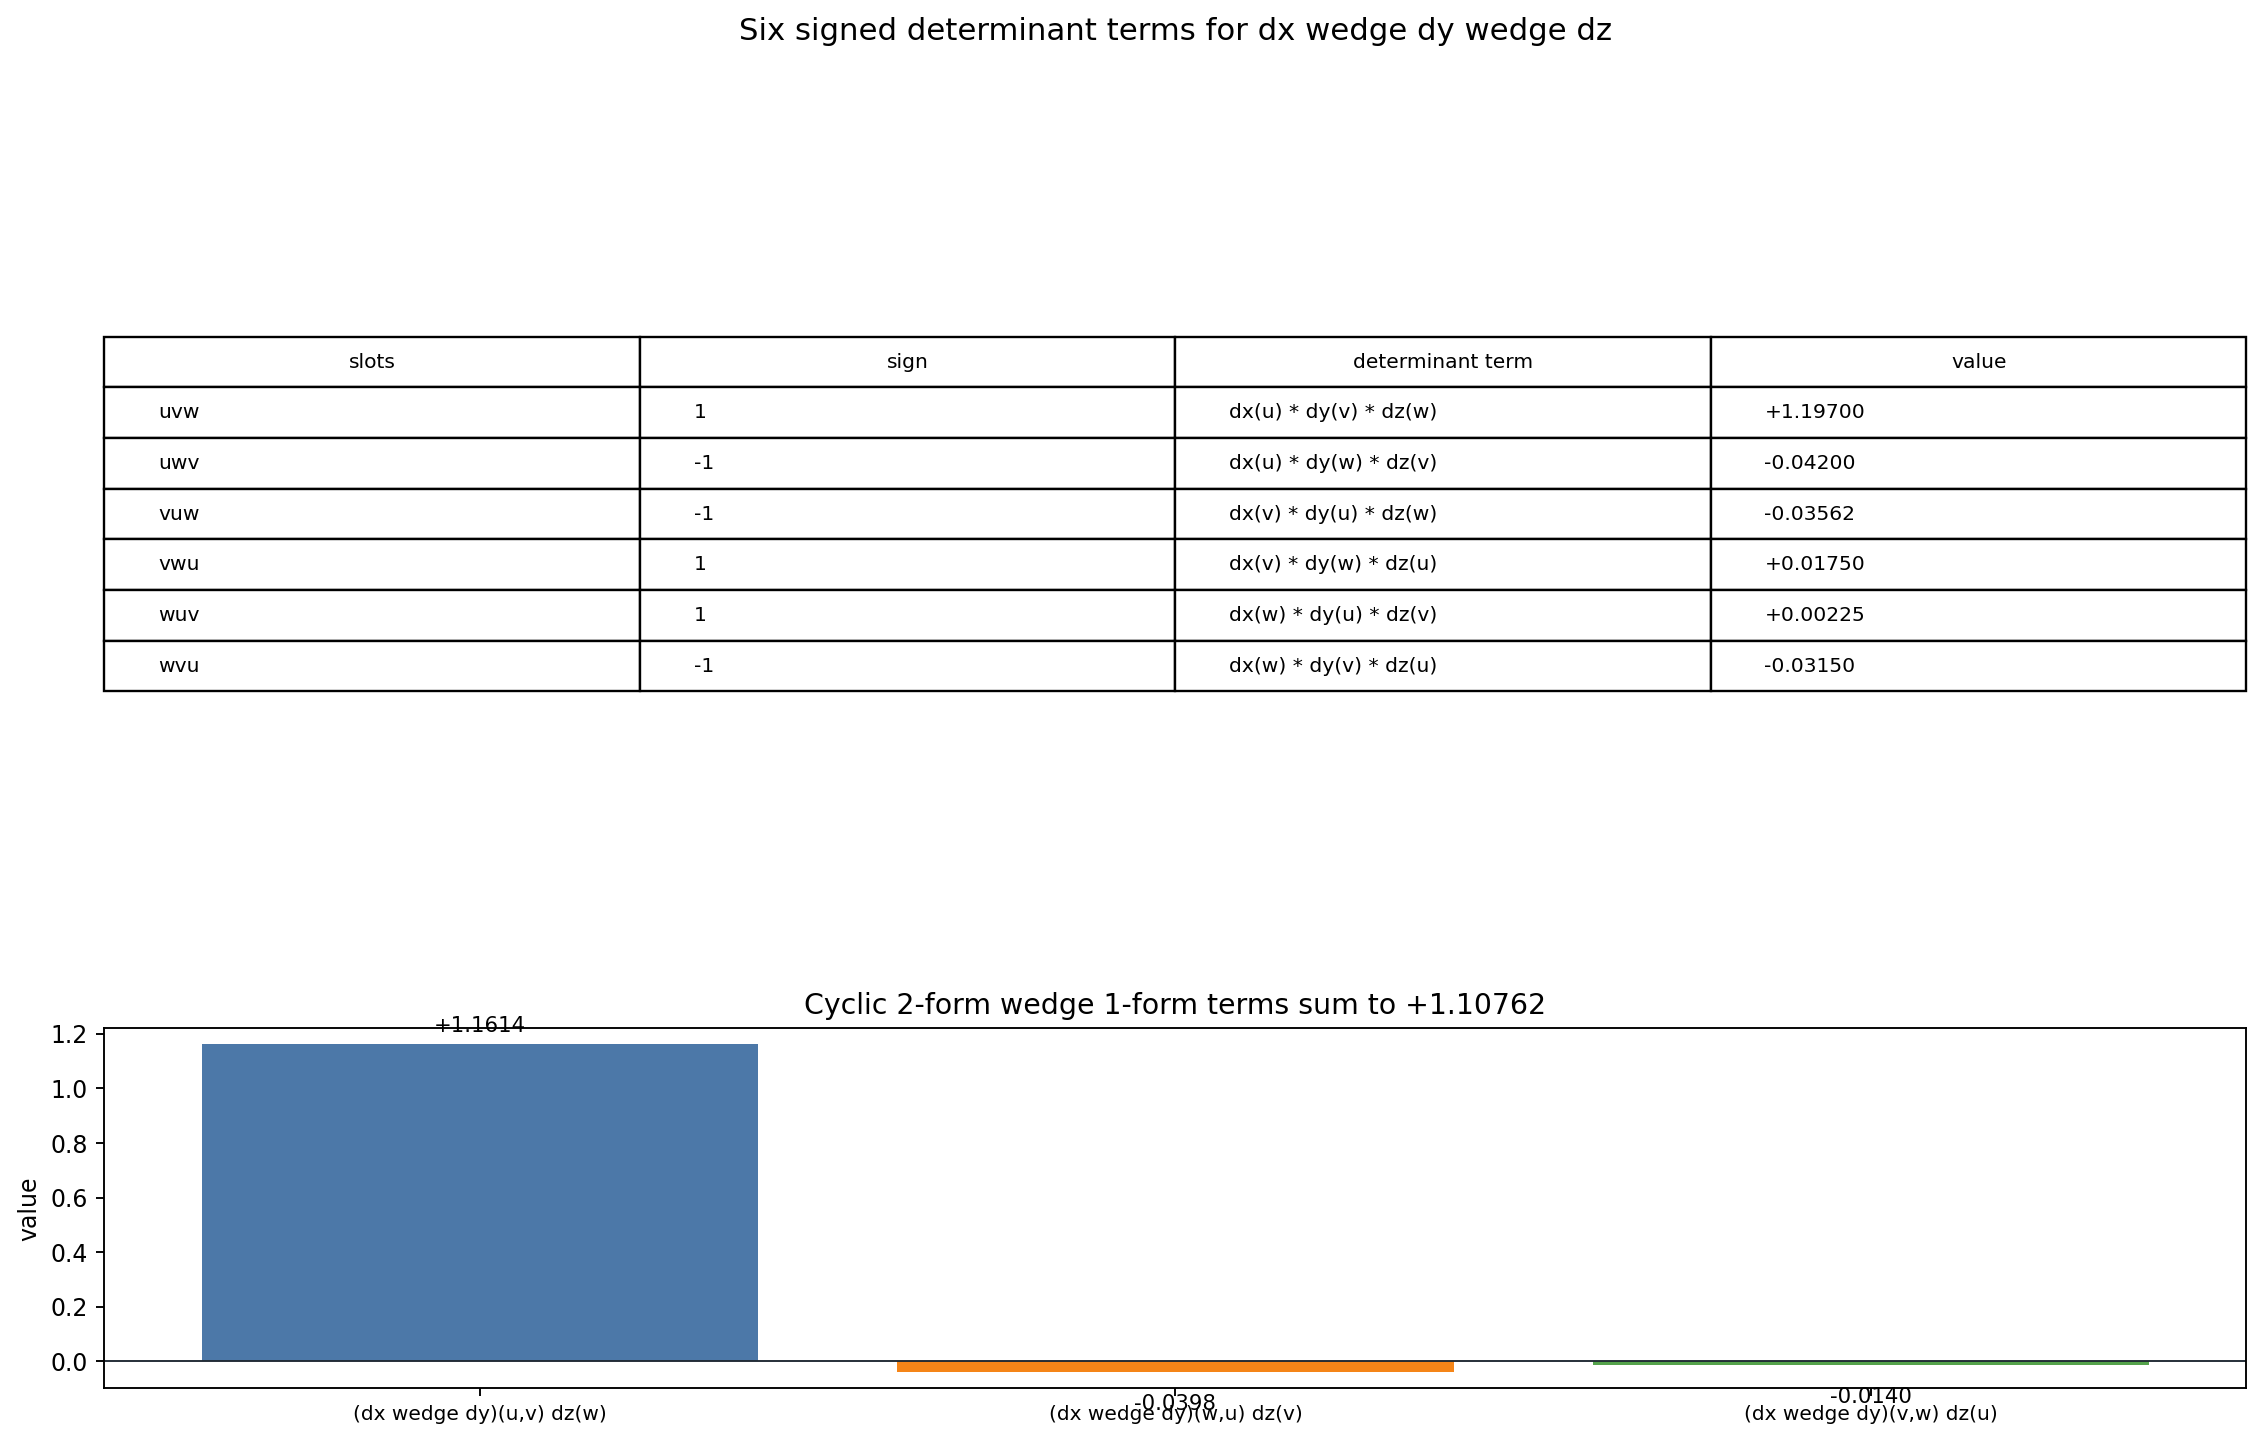

artifacts/chapter-35/checks/wedge-determinant-checks.json


In [6]:
dx = np.array([1.0, 0.0, 0.0])
dy = np.array([0.0, 1.0, 0.0])
dz = np.array([0.0, 0.0, 1.0])
vectors = [u, v, w]
vector_names = ["u", "v", "w"]
forms = [dx, dy, dz]
form_names = ["dx", "dy", "dz"]


def eval_one_form(alpha: np.ndarray, vector: np.ndarray) -> float:
    return float(np.dot(alpha, vector))


def eval_two_form(alpha: np.ndarray, beta: np.ndarray, a: np.ndarray, b: np.ndarray) -> float:
    return eval_one_form(alpha, a) * eval_one_form(beta, b) - eval_one_form(alpha, b) * eval_one_form(beta, a)


def permutation_parity(perm: tuple[int, ...]) -> int:
    inversions = sum(1 for i in range(len(perm)) for j in range(i + 1, len(perm)) if perm[i] > perm[j])
    return -1 if inversions % 2 else 1


matrix = np.array([[eval_one_form(alpha, vec) for vec in vectors] for alpha in forms], dtype=float)
determinant_value = float(np.linalg.det(matrix))
ledger_rows = []
for perm in itertools.permutations(range(3)):
    sign = permutation_parity(perm)
    factors = [matrix[row, perm[row]] for row in range(3)]
    ledger_rows.append(
        {
            "permutation_of_vector_slots": "".join(vector_names[i] for i in perm),
            "sign": sign,
            "term": " * ".join(f"{form_names[row]}({vector_names[perm[row]]})" for row in range(3)),
            "numeric_product": float(np.prod(factors)),
            "signed_value": float(sign * np.prod(factors)),
        }
    )
ledger_df = pd.DataFrame(ledger_rows)
ledger_sum = float(ledger_df["signed_value"].sum())

cyclic_rows = [
    {"cyclic_term": "(dx wedge dy)(u,v) dz(w)", "value": eval_two_form(dx, dy, u, v) * eval_one_form(dz, w)},
    {"cyclic_term": "(dx wedge dy)(w,u) dz(v)", "value": eval_two_form(dx, dy, w, u) * eval_one_form(dz, v)},
    {"cyclic_term": "(dx wedge dy)(v,w) dz(u)", "value": eval_two_form(dx, dy, v, w) * eval_one_form(dz, u)},
]
cyclic_df = pd.DataFrame(cyclic_rows)
cyclic_sum = float(cyclic_df["value"].sum())

table_path = artifact_path(ARTIFACT_TOPIC, "tables", "wedge-product-determinant-ledger.csv", root=ARTIFACT_BASE)
ledger_df.to_csv(table_path, index=False)
record_table(table_path, "six signed terms for dx wedge dy wedge dz")
cyclic_path = artifact_path(ARTIFACT_TOPIC, "tables", "wedge-product-cyclic-2form-1form-ledger.csv", root=ARTIFACT_BASE)
cyclic_df.to_csv(cyclic_path, index=False)
record_table(cyclic_path, "three cyclic terms for (dx wedge dy) wedge dz")

fig, axes = plt.subplots(2, 1, figsize=(13.5, 8.6), gridspec_kw={"height_ratios": [2.5, 1]})
axes[0].axis("off")
table_cols = ["permutation_of_vector_slots", "sign", "term", "signed_value"]
table_data = ledger_df[table_cols].copy()
table_data["signed_value"] = table_data["signed_value"].map(lambda x: f"{x:+.5f}")
tab = axes[0].table(cellText=table_data.values, colLabels=["slots", "sign", "determinant term", "value"], loc="center", cellLoc="left")
tab.auto_set_font_size(False)
tab.set_fontsize(8.6)
tab.scale(1, 1.45)
axes[0].set_title("Six signed determinant terms for dx wedge dy wedge dz", fontsize=13, pad=10)

axes[1].bar(range(len(cyclic_df)), cyclic_df["value"], color=["#4c78a8", "#f58518", "#54a24b"])
axes[1].axhline(0, color="#1f2933", linewidth=0.8)
axes[1].set_xticks(range(len(cyclic_df)))
axes[1].set_xticklabels(cyclic_df["cyclic_term"], rotation=0, ha="center", fontsize=8.5)
axes[1].set_ylabel("value")
axes[1].set_title(f"Cyclic 2-form wedge 1-form terms sum to {cyclic_sum:+.5f}", fontsize=12)
for index, value in enumerate(cyclic_df["value"]):
    axes[1].text(index, value + (0.03 if value >= 0 else -0.08), f"{value:+.4f}", ha="center", va="bottom" if value >= 0 else "top", fontsize=9)
fig.tight_layout()
ledger_png = save_figure(
    fig,
    "wedge-product-determinant-ledger.png",
    concept="wedge product determinant ledger",
    kind="ledger figure",
    inspection_target="Compare the six signed determinant terms with the three cyclic terms of (dx wedge dy) wedge dz.",
)

wedge_checks = {
    "evaluation_matrix_rows_dx_dy_dz_cols_u_v_w": matrix.tolist(),
    "determinant_value": determinant_value,
    "six_term_ledger_sum": ledger_sum,
    "cyclic_2form_1form_sum": cyclic_sum,
    "determinant_equals_six_term_sum": abs(determinant_value - ledger_sum) < 1e-12,
    "determinant_equals_cyclic_sum": abs(determinant_value - cyclic_sum) < 1e-12,
    "graded_commutativity_sign_for_2_and_1": (-1) ** (2 * 1),
}
assert wedge_checks["determinant_equals_six_term_sum"]
assert wedge_checks["determinant_equals_cyclic_sum"]
assert wedge_checks["graded_commutativity_sign_for_2_and_1"] == 1
wedge_check_path = save_check(wedge_checks, "wedge-determinant-checks.json")
validation_data["wedge_determinant"] = wedge_checks

display_artifact(ledger_png, width=860)
display_artifact(table_path)
display_artifact(cyclic_path)
print(rel(wedge_check_path))

## Pulling The Volume Form Into Spherical Coordinates

The coordinate formulas `x = r sin(phi) cos(theta)`, `y = r sin(phi) sin(theta)`, and `z = r cos(phi)` define a map from coordinate space `(r, phi, theta)` into ordinary space. Pulling back `dx wedge dy wedge dz` means replacing `dx`, `dy`, and `dz` by their differentials in the new coordinates and keeping the coefficient of `dr wedge dphi wedge dtheta`.

For a top-degree form, that coefficient is the Jacobian determinant. The symbolic check below proves the coefficient exactly. The figure shows why the factor has the shape it does: the small coordinate edges have lengths approximately `dr`, `r dphi`, and `r sin(phi) dtheta`, so their product is `r**2 sin(phi) dr dphi dtheta`.

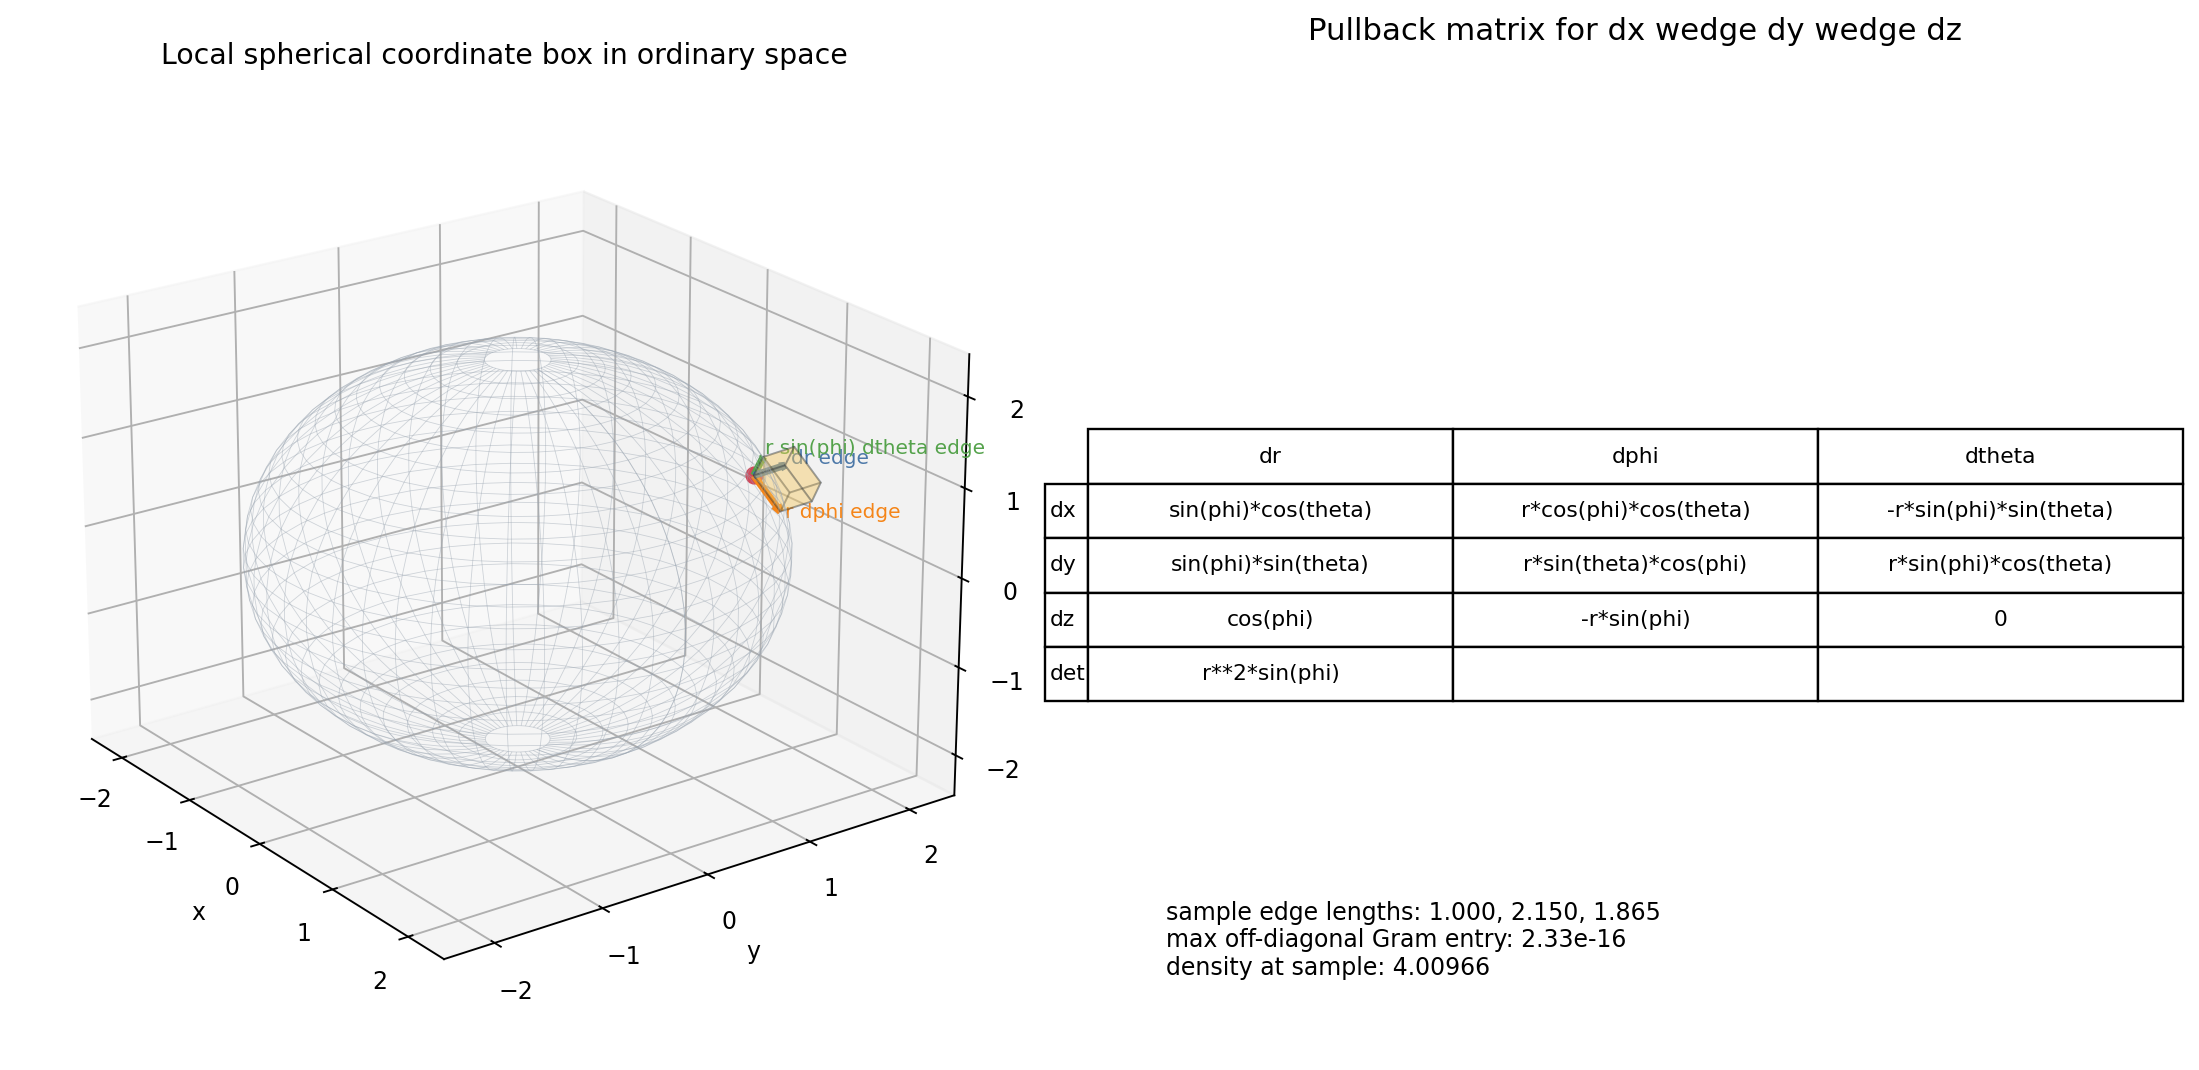

artifacts/chapter-35/checks/spherical-volume-jacobian-checks.json


In [7]:
r, phi, theta = sp.symbols("r phi theta", positive=True, real=True)
x_expr = r * sp.sin(phi) * sp.cos(theta)
y_expr = r * sp.sin(phi) * sp.sin(theta)
z_expr = r * sp.cos(phi)
J = sp.Matrix(
    [
        [sp.diff(x_expr, r), sp.diff(x_expr, phi), sp.diff(x_expr, theta)],
        [sp.diff(y_expr, r), sp.diff(y_expr, phi), sp.diff(y_expr, theta)],
        [sp.diff(z_expr, r), sp.diff(z_expr, phi), sp.diff(z_expr, theta)],
    ]
)
jacobian_det = sp.simplify(J.det())
expected_jacobian = r**2 * sp.sin(phi)

r0, phi0, theta0 = 2.15, 1.05, 0.72
J_num = np.array(J.subs({r: r0, phi: phi0, theta: theta0}), dtype=float)
gram = J_num.T @ J_num
edge_lengths = np.sqrt(np.diag(gram))
off_diagonal = gram - np.diag(np.diag(gram))
local_density = float(np.linalg.det(J_num))
expected_density = float((r**2 * sp.sin(phi)).subs({r: r0, phi: phi0}))

point = np.array([
    float(x_expr.subs({r: r0, phi: phi0, theta: theta0})),
    float(y_expr.subs({r: r0, phi: phi0, theta: theta0})),
    float(z_expr.subs({r: r0, phi: phi0, theta: theta0})),
])
edge_scale = np.array([0.28, 0.20, 0.22])
local_edges = [J_num[:, i] * edge_scale[i] for i in range(3)]

fig = plt.figure(figsize=(13.2, 6.4))
ax = fig.add_subplot(1, 2, 1, projection="3d")
phi_grid = np.linspace(0.12, math.pi - 0.12, 30)
theta_grid = np.linspace(0, 2 * math.pi, 48)
Phi, Theta = np.meshgrid(phi_grid, theta_grid)
X = r0 * np.sin(Phi) * np.cos(Theta)
Y = r0 * np.sin(Phi) * np.sin(Theta)
Z = r0 * np.cos(Phi)
ax.plot_wireframe(X, Y, Z, color="#9aa5b1", linewidth=0.35, alpha=0.45)
ax.scatter(*point, color="#d1495b", s=45, label="sample point")
edge_colors = ["#4c78a8", "#f58518", "#54a24b"]
edge_labels = ["dr edge", "r dphi edge", "r sin(phi) dtheta edge"]
for edge, color, label in zip(local_edges, edge_colors, edge_labels):
    ax.quiver(point[0], point[1], point[2], edge[0], edge[1], edge[2], color=color, linewidth=3, arrow_length_ratio=0.18)
    ax.text(*(point + 1.18 * edge), label, color=color, fontsize=8.5)
local_vertices = np.array([point, point + local_edges[0], point + local_edges[1], point + local_edges[2], point + local_edges[0] + local_edges[1], point + local_edges[0] + local_edges[2], point + local_edges[1] + local_edges[2], point + local_edges[0] + local_edges[1] + local_edges[2]])
poly = Poly3DCollection(local_vertices[faces], alpha=0.25, facecolor="#f6c85f", edgecolor="#1f2933", linewidth=0.8)
ax.add_collection3d(poly)
ax.set_title("Local spherical coordinate box in ordinary space")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
set_axes_equal(ax)
ax.view_init(elev=22, azim=-36)

ax2 = fig.add_subplot(1, 2, 2)
ax2.axis("off")
rows = ["dx", "dy", "dz", "det"]
cols = ["dr", "dphi", "dtheta"]
matrix_text = [[sp.sstr(sp.simplify(J[row, col])) for col in range(3)] for row in range(3)]
matrix_text.append([sp.sstr(jacobian_det), "", ""])
tab = ax2.table(cellText=matrix_text, rowLabels=rows, colLabels=cols, loc="center", cellLoc="center")
tab.auto_set_font_size(False)
tab.set_fontsize(9.2)
tab.scale(1.05, 1.65)
ax2.set_title("Pullback matrix for dx wedge dy wedge dz", fontsize=13, pad=16)
ax2.text(0.05, 0.08, f"sample edge lengths: {edge_lengths[0]:.3f}, {edge_lengths[1]:.3f}, {edge_lengths[2]:.3f}\nmax off-diagonal Gram entry: {np.abs(off_diagonal).max():.2e}\ndensity at sample: {local_density:.5f}", fontsize=10, transform=ax2.transAxes)
fig.tight_layout()
spherical_png = save_figure(
    fig,
    "spherical-volume-jacobian.png",
    concept="spherical volume Jacobian",
    kind="figure",
    inspection_target="At a point, the three coordinate edge lengths multiply to the pullback density r**2 sin(phi).",
)

r_values = np.linspace(0.05, 3.0, 90)
phi_values = np.linspace(0.02, math.pi - 0.02, 90)
R, P = np.meshgrid(r_values, phi_values)
Density = R**2 * np.sin(P)
density_fig = go.Figure(data=[go.Surface(x=R, y=P, z=Density, colorscale="Viridis", colorbar=dict(title="density"))])
density_fig.update_layout(
    title="Pullback density for dx wedge dy wedge dz under spherical coordinates",
    scene=dict(xaxis_title="r", yaxis_title="phi", zaxis_title="r^2 sin(phi)"),
    margin=dict(l=0, r=0, t=50, b=0),
)
density_html = save_plotly_html(density_fig, ARTIFACT_TOPIC, "html", "spherical-volume-pullback-density.html", root=ARTIFACT_BASE)
record_artifact(
    density_html,
    concept="spherical pullback volume density",
    kind="html",
    inspection_target="Inspect how radius and polar angle change the coordinate volume multiplier r**2 sin(phi).",
)

spherical_checks = {
    "jacobian_matrix": [[sp.sstr(sp.simplify(entry)) for entry in row] for row in J.tolist()],
    "jacobian_determinant": sp.sstr(jacobian_det),
    "expected_determinant": sp.sstr(expected_jacobian),
    "symbolic_jacobian_matches": bool(sp.simplify(jacobian_det - expected_jacobian) == 0),
    "sample_point": {"r": r0, "phi": phi0, "theta": theta0},
    "sample_edge_lengths": edge_lengths.tolist(),
    "sample_density": local_density,
    "sample_expected_density": expected_density,
    "sample_density_matches": abs(local_density - expected_density) < 1e-12,
    "coordinate_edges_are_orthogonal_at_sample": float(np.abs(off_diagonal).max()) < 1e-12,
}
assert spherical_checks["symbolic_jacobian_matches"]
assert spherical_checks["sample_density_matches"]
assert spherical_checks["coordinate_edges_are_orthogonal_at_sample"]
spherical_check_path = save_check(spherical_checks, "spherical-volume-jacobian-checks.json")
validation_data["spherical_pullback"] = spherical_checks

display_artifact(spherical_png, width=860)
display_artifact(density_html, width="100%", height=500)
print(rel(spherical_check_path))

## Basis 3-Form Ledgers And Graded Signs

A basis 3-form is indexed by three distinct coordinate 1-forms. That is why the count is `C(n, 3)`: choose three distinct labels from `n`, then orient them. In `R^3`, every 3-form is a scalar multiple of the single top form `dx1 wedge dx2 wedge dx3`. In `R^4`, there are four independent 3-form slots.

The second visual records the swap-count proof for graded commutativity. Moving a `p`-form past a `q`-form means moving `p` one-form factors through `q` one-form factors, for `p*q` swaps and sign `(-1)**(p*q)`. This explains why a 2-form commutes with a 1-form, while odd-degree self-wedges vanish by sign.

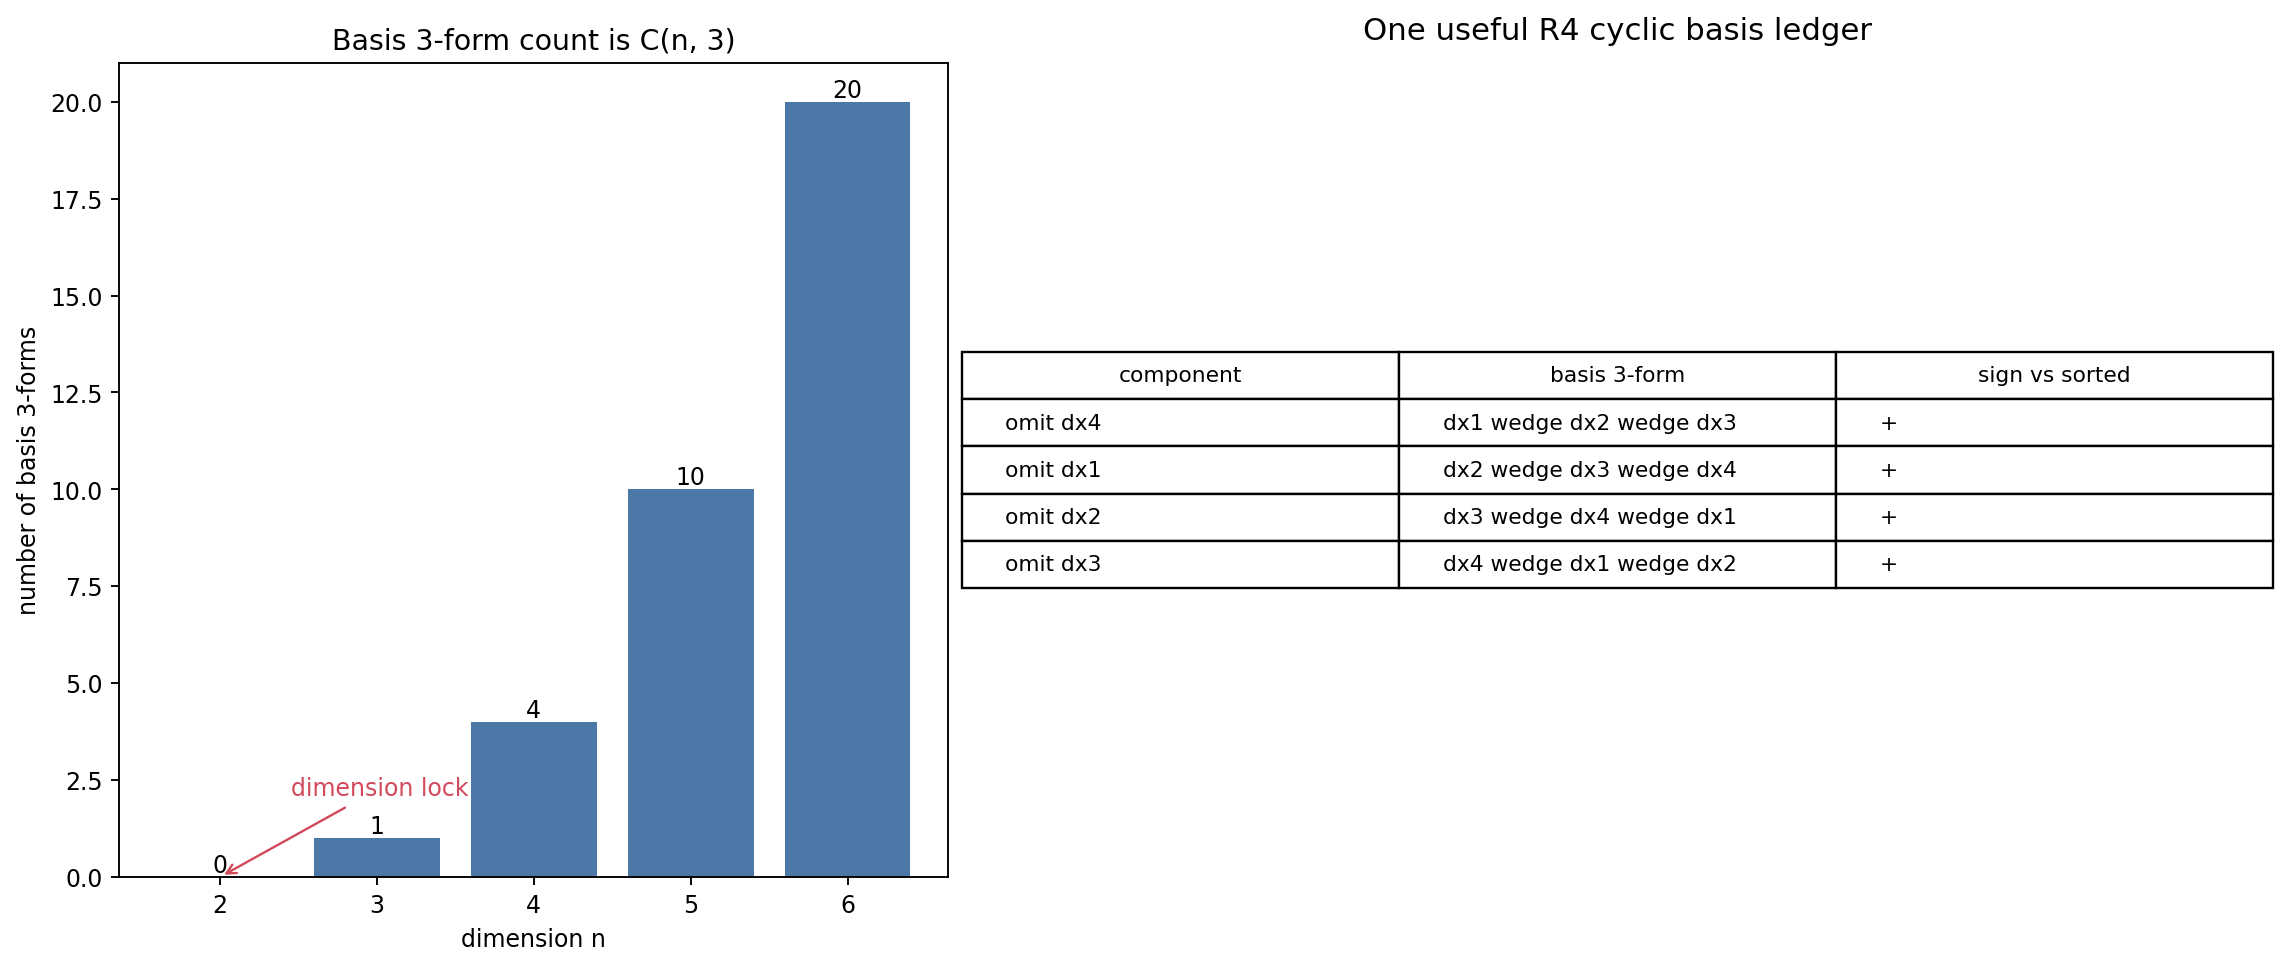

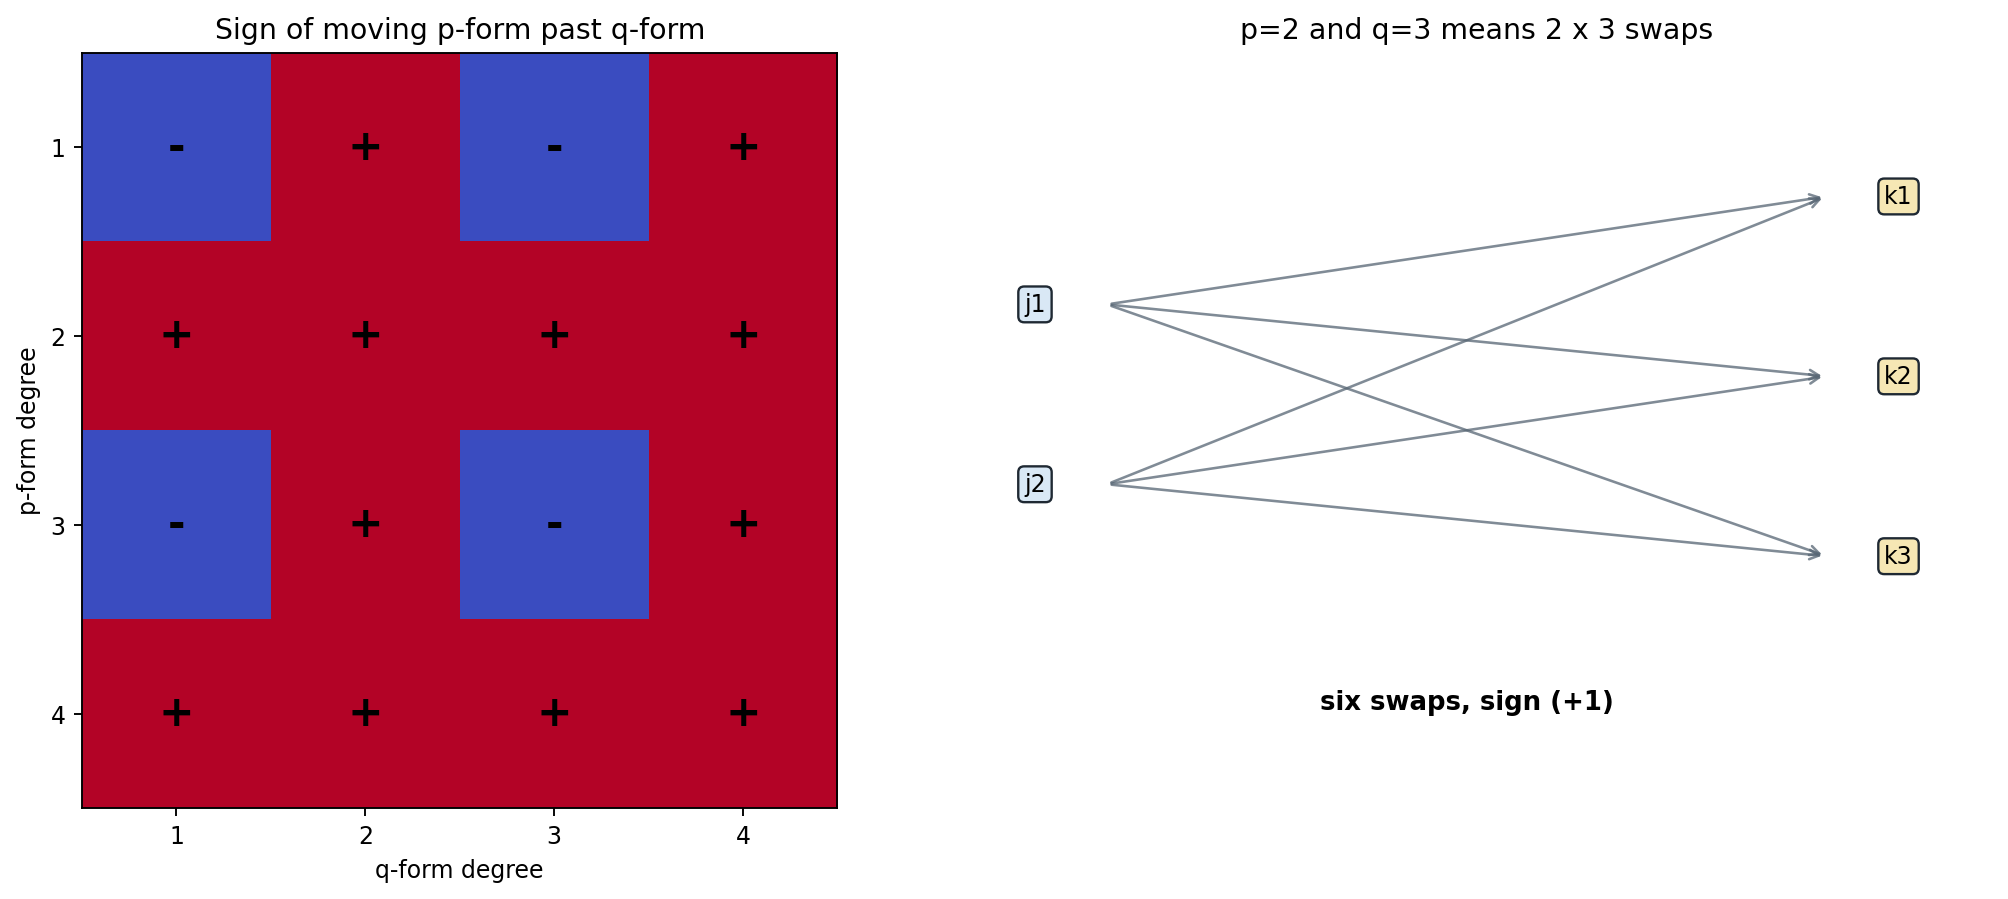

artifacts/chapter-35/checks/basis-and-graded-sign-checks.json


In [8]:
basis_rows = []
for n in range(2, 7):
    triples = list(itertools.combinations(range(1, n + 1), 3))
    basis_rows.append(
        {
            "dimension": n,
            "basis_3form_count": len(triples),
            "binomial_n_choose_3": math.comb(n, 3),
            "basis_triples": "; ".join("dx" + "^dx".join(map(str, triple)) for triple in triples) if triples else "none",
            "dimension_lock": "locked: no 3 independent basis directions" if len(triples) == 0 else "unlocked",
        }
    )
basis_df = pd.DataFrame(basis_rows)
basis_table_path = artifact_path(ARTIFACT_TOPIC, "tables", "basis-3-form-ledger.csv", root=ARTIFACT_BASE)
basis_df.to_csv(basis_table_path, index=False)
record_table(basis_table_path, "basis 3-form counts by dimension")

r4_cyclic_terms = [
    ("omit dx4", (1, 2, 3)),
    ("omit dx1", (2, 3, 4)),
    ("omit dx2", (3, 4, 1)),
    ("omit dx3", (4, 1, 2)),
]
r4_rows = []
for label, triple in r4_cyclic_terms:
    ranks = list(triple)
    inversions = sum(1 for i in range(3) for j in range(i + 1, 3) if ranks[i] > ranks[j])
    canonical = tuple(sorted(triple))
    r4_rows.append(
        {
            "cyclic_component": label,
            "oriented_basis_3form": " wedge ".join(f"dx{i}" for i in triple),
            "canonical_triple": canonical,
            "sign_against_ascending_order": -1 if inversions % 2 else 1,
        }
    )
r4_df = pd.DataFrame(r4_rows)
r4_table_path = artifact_path(ARTIFACT_TOPIC, "tables", "r4-cyclic-basis-3form-ledger.csv", root=ARTIFACT_BASE)
r4_df.to_csv(r4_table_path, index=False)
record_table(r4_table_path, "cyclic R4 basis 3-form ledger")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.8), gridspec_kw={"width_ratios": [0.82, 1.18]})
axes[0].bar(basis_df["dimension"], basis_df["basis_3form_count"], color="#4c78a8")
axes[0].set_title("Basis 3-form count is C(n, 3)")
axes[0].set_xlabel("dimension n")
axes[0].set_ylabel("number of basis 3-forms")
axes[0].set_xticks(basis_df["dimension"])
for _, row in basis_df.iterrows():
    axes[0].text(row["dimension"], row["basis_3form_count"] + 0.12, str(row["basis_3form_count"]), ha="center")
axes[0].annotate("dimension lock", xy=(2, 0), xytext=(2.45, 2.1), arrowprops=dict(arrowstyle="->", color="#d1495b"), color="#d1495b")

axes[1].axis("off")
table_data = r4_df[["cyclic_component", "oriented_basis_3form", "sign_against_ascending_order"]].copy()
table_data["sign_against_ascending_order"] = table_data["sign_against_ascending_order"].map(lambda s: "+" if s > 0 else "-")
tab = axes[1].table(cellText=table_data.values, colLabels=["component", "basis 3-form", "sign vs sorted"], loc="center", cellLoc="left")
tab.auto_set_font_size(False)
tab.set_fontsize(9.2)
tab.scale(1.1, 1.55)
axes[1].set_title("One useful R4 cyclic basis ledger", fontsize=13, pad=10)
fig.tight_layout()
basis_png = save_figure(
    fig,
    "basis-3-form-ledger.png",
    concept="basis 3-form ledger",
    kind="ledger figure",
    inspection_target="Read off why R2 has no basis 3-forms, R3 has one, and R4 has four.",
)

p_values = np.arange(1, 5)
q_values = np.arange(1, 5)
sign_grid = np.array([[(-1) ** (p * q) for q in q_values] for p in p_values])
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4), gridspec_kw={"width_ratios": [1.0, 1.05]})
axes[0].imshow(sign_grid, cmap="coolwarm", vmin=-1, vmax=1)
axes[0].set_xticks(range(len(q_values)), labels=q_values)
axes[0].set_yticks(range(len(p_values)), labels=p_values)
axes[0].set_xlabel("q-form degree")
axes[0].set_ylabel("p-form degree")
axes[0].set_title("Sign of moving p-form past q-form")
for i_row, p in enumerate(p_values):
    for j_col, q in enumerate(q_values):
        axes[0].text(j_col, i_row, "+" if sign_grid[i_row, j_col] > 0 else "-", ha="center", va="center", fontsize=18, fontweight="bold")

axes[1].set_xlim(0, 5)
axes[1].set_ylim(0, 4.2)
axes[1].axis("off")
axes[1].set_title("p=2 and q=3 means 2 x 3 swaps")
left_y = [2.8, 1.8]
right_y = [3.4, 2.4, 1.4]
for idx, y in enumerate(left_y, start=1):
    axes[1].text(0.35, y, f"j{idx}", ha="center", va="center", bbox=dict(boxstyle="round,pad=0.25", facecolor="#d9e8f5", edgecolor="#1f2933"))
for idx, y in enumerate(right_y, start=1):
    axes[1].text(4.55, y, f"k{idx}", ha="center", va="center", bbox=dict(boxstyle="round,pad=0.25", facecolor="#f6e7b4", edgecolor="#1f2933"))
for y1 in left_y:
    for y2 in right_y:
        arrow = FancyArrowPatch((0.7, y1), (4.2, y2), arrowstyle="->", mutation_scale=10, linewidth=1.1, color="#566573", alpha=0.75)
        axes[1].add_patch(arrow)
axes[1].text(2.45, 0.55, "six swaps, sign (+1)", ha="center", fontsize=11, fontweight="bold")
fig.tight_layout()
graded_png = save_figure(
    fig,
    "graded-commutativity-swap-ledger.png",
    concept="graded commutativity swap ledger",
    kind="proof ledger",
    inspection_target="Count p*q crossings to predict whether reversing two wedge factors changes the sign.",
)

basis_checks = {
    "basis_counts_match_binomial": bool((basis_df["basis_3form_count"] == basis_df["binomial_n_choose_3"]).all()),
    "basis_counts_by_dimension": {str(row["dimension"]): int(row["basis_3form_count"]) for _, row in basis_df.iterrows()},
    "r4_cyclic_signs_all_positive_against_ascending_order": bool((r4_df["sign_against_ascending_order"] == 1).all()),
    "graded_sign_grid": sign_grid.astype(int).tolist(),
    "sign_2_1": int((-1) ** (2 * 1)),
    "sign_3_3": int((-1) ** (3 * 3)),
    "odd_degree_self_wedge_forced_zero_by_sign": int((-1) ** (3 * 3)) == -1,
    "even_degree_two_form_self_wedge_example": form_to_strings(psi_square),
}
assert basis_checks["basis_counts_match_binomial"]
assert basis_checks["r4_cyclic_signs_all_positive_against_ascending_order"]
assert basis_checks["sign_2_1"] == 1
assert basis_checks["sign_3_3"] == -1
assert basis_checks["even_degree_two_form_self_wedge_example"] == {"t^x^y^z": 2.0}
basis_check_path = save_check(basis_checks, "basis-and-graded-sign-checks.json")
validation_data["basis_and_graded_signs"] = basis_checks

display_artifact(basis_png, width=860)
display_artifact(graded_png, width=820)
display_artifact(basis_table_path)
display_artifact(r4_table_path)
print(rel(basis_check_path))

## Applied Lab: Calibrating A 3-Form Volume Meter

A useful way to test a volume form is to treat it like an instrument. Feed it several triples of edge vectors. Then deliberately introduce three faults:

1. swap two slots;
2. repeat a slot;
3. apply a linear coordinate change.

A correct 3-form meter flips sign in the first test, gives zero in the second, and scales by the determinant of the linear map in the third. The bar chart is a compact calibration report.

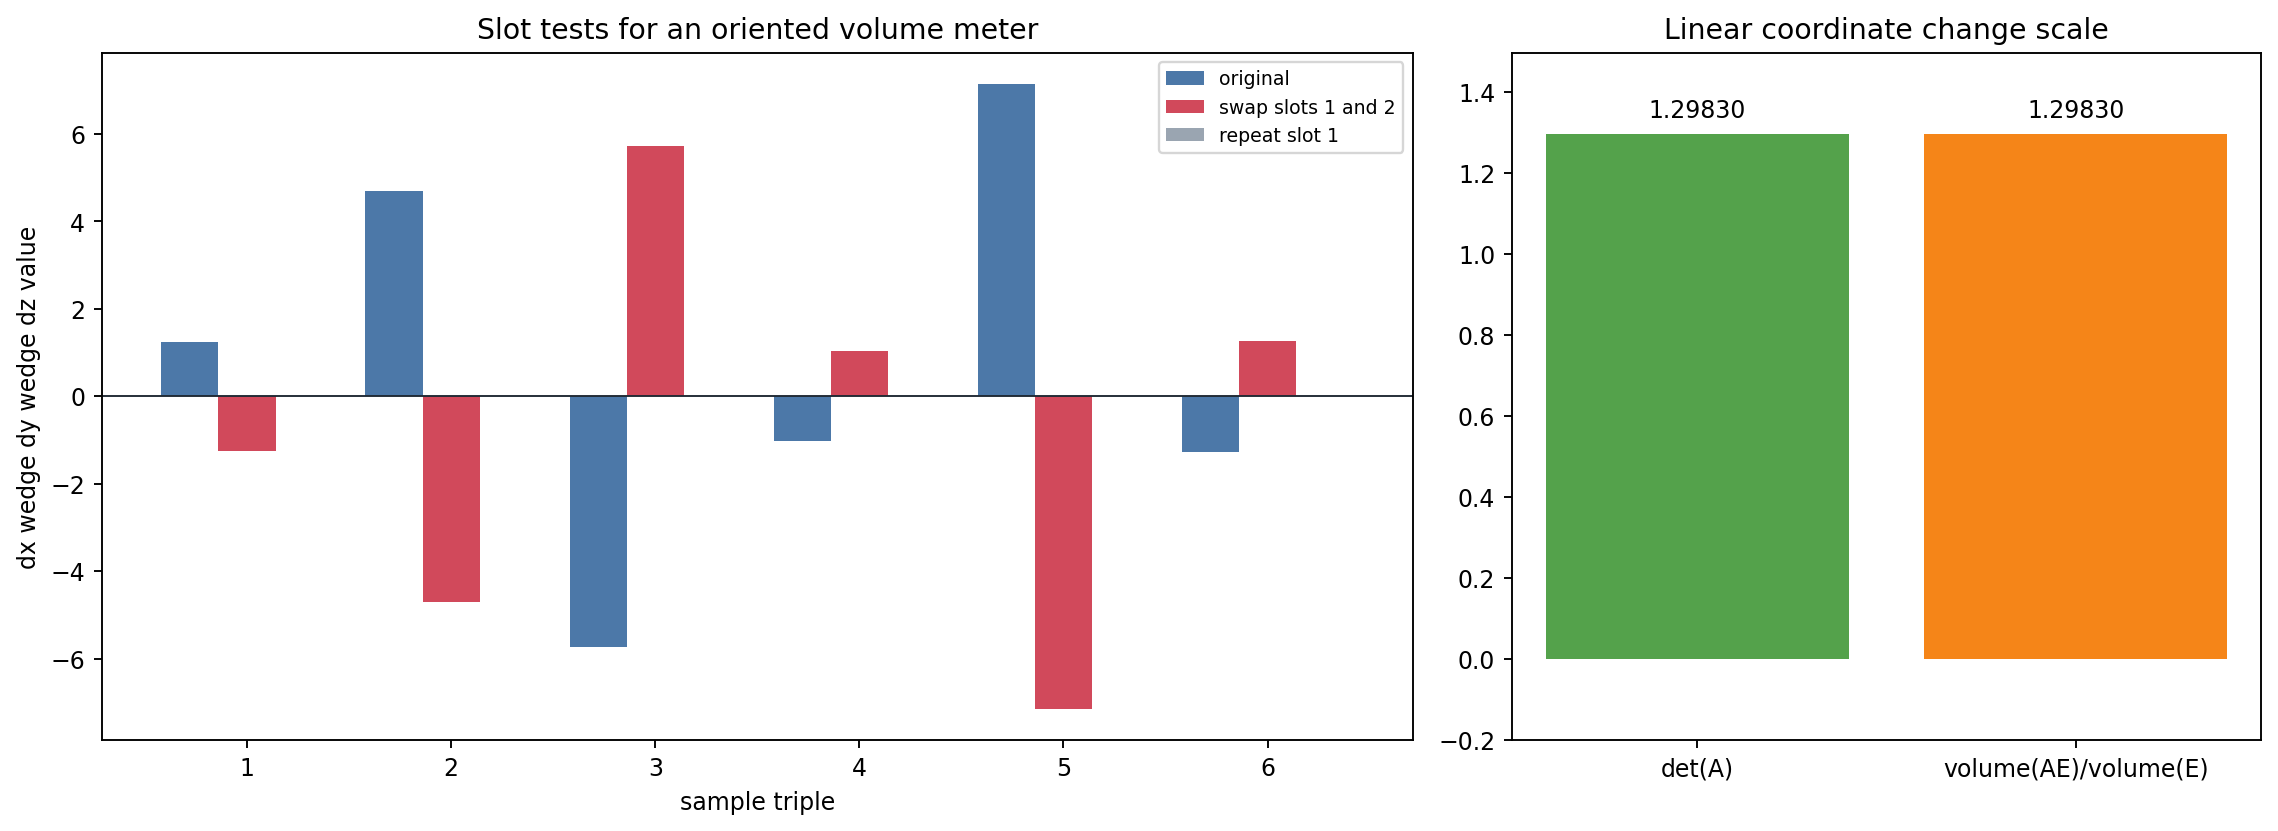

artifacts/chapter-35/checks/orientation-lab-checks.json


In [9]:
rng = np.random.default_rng(35)
sample_rows = []
for index in range(6):
    E = rng.normal(size=(3, 3))
    original = float(np.linalg.det(E))
    swapped = float(np.linalg.det(E[:, [1, 0, 2]]))
    repeated = float(np.linalg.det(np.column_stack([E[:, 0], E[:, 0], E[:, 2]])))
    sample_rows.append({"sample": index + 1, "original": original, "swapped_slots_1_2": swapped, "repeated_slots_1_2": repeated})
lab_df = pd.DataFrame(sample_rows)

A = np.array([[1.15, 0.20, 0.00], [0.10, 0.90, -0.15], [0.05, 0.18, 1.25]])
linear_det = float(np.linalg.det(A))
probe = rng.normal(size=(3, 3))
probe_volume = float(np.linalg.det(probe))
transformed_volume = float(np.linalg.det(A @ probe))
linear_scaling_ratio = transformed_volume / probe_volume

lab_table_path = artifact_path(ARTIFACT_TOPIC, "tables", "three-form-orientation-lab-samples.csv", root=ARTIFACT_BASE)
lab_df.to_csv(lab_table_path, index=False)
record_table(lab_table_path, "orientation lab determinant samples")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0), gridspec_kw={"width_ratios": [1.4, 0.8]})
xpos = np.arange(len(lab_df))
width = 0.28
axes[0].bar(xpos - width, lab_df["original"], width=width, label="original", color="#4c78a8")
axes[0].bar(xpos, lab_df["swapped_slots_1_2"], width=width, label="swap slots 1 and 2", color="#d1495b")
axes[0].bar(xpos + width, lab_df["repeated_slots_1_2"], width=width, label="repeat slot 1", color="#9aa5b1")
axes[0].axhline(0, color="#1f2933", linewidth=0.8)
axes[0].set_xticks(xpos, labels=lab_df["sample"])
axes[0].set_xlabel("sample triple")
axes[0].set_ylabel("dx wedge dy wedge dz value")
axes[0].set_title("Slot tests for an oriented volume meter")
axes[0].legend(fontsize=8)

axes[1].bar(["det(A)", "volume(AE)/volume(E)"], [linear_det, linear_scaling_ratio], color=["#54a24b", "#f58518"])
axes[1].set_title("Linear coordinate change scale")
axes[1].set_ylim(min(0, linear_det, linear_scaling_ratio) - 0.2, max(linear_det, linear_scaling_ratio) + 0.2)
for index, value in enumerate([linear_det, linear_scaling_ratio]):
    axes[1].text(index, value + 0.04, f"{value:.5f}", ha="center")
fig.tight_layout()
lab_png = save_figure(
    fig,
    "three-form-orientation-lab.png",
    concept="three-form orientation lab",
    kind="lab figure",
    inspection_target="Check that a volume meter flips sign under swaps, vanishes with repeated slots, and scales by det(A).",
)

lab_checks = {
    "all_swaps_flip_sign": bool(np.allclose(lab_df["original"] + lab_df["swapped_slots_1_2"], 0.0, atol=1e-12)),
    "all_repeated_slots_zero": bool(np.allclose(lab_df["repeated_slots_1_2"], 0.0, atol=1e-12)),
    "linear_map_determinant": linear_det,
    "linear_scaling_ratio": linear_scaling_ratio,
    "linear_scaling_matches_det": abs(linear_scaling_ratio - linear_det) < 1e-12,
}
assert lab_checks["all_swaps_flip_sign"]
assert lab_checks["all_repeated_slots_zero"]
assert lab_checks["linear_scaling_matches_det"]
lab_check_path = save_check(lab_checks, "orientation-lab-checks.json")
validation_data["orientation_lab"] = lab_checks

display_artifact(lab_png, width=840)
display_artifact(lab_table_path)
print(rel(lab_check_path))

## Final Sanity Checks And Takeaways

The chapter has one central invariant with many faces: a 3-form measures oriented volume. The determinant picture, the wedge-product ledger, and the pullback calculation are not separate tricks. They are the same alternating measurement viewed from different interfaces.

Key takeaways:

- A nonzero 3-form needs three independent directions. In `R^2`, every three-slot basis component repeats a direction and vanishes.
- `dx wedge dy wedge dz` evaluates three edge vectors as an oriented determinant.
- The wedge of a 2-form and a 1-form commutes because `(-1)**(2*1)=+1`; the wedge of two odd-degree copies is forced to vanish by the sign rule.
- Pulling the Euclidean volume form back through spherical coordinates contributes the determinant `r**2 sin(phi)`.
- Basis 3-forms are counted by `C(n,3)`, with one top form in `R^3` and four independent 3-form slots in `R^4`.

The final cell writes the chapter check payload and asserts artifact integrity, nonblank image statistics, and the chapter-specific symbolic/numeric identities.

In [10]:
required_storyboard_topics = [
    "oriented volume box determinant",
    "repeated direction vanishing proof",
    "wedge product determinant ledger",
    "spherical volume Jacobian and pullback density",
    "basis 3-form ledger",
    "graded commutativity swap ledger",
    "orientation lab",
]

artifact_sizes_ok = all((BOOK_ROOT / item["relative_path"]).exists() and (BOOK_ROOT / item["relative_path"]).stat().st_size > 1000 for item in artifact_records.values())
image_stats_ok = all(
    (item["metrics"].get("pixel_std", 2.0) > 1.0) for item in artifact_records.values() if item["relative_path"].endswith(".png")
)
table_sizes_ok = all((BOOK_ROOT / path).exists() and (BOOK_ROOT / path).stat().st_size > 40 for path in table_records)
check_sizes_ok = all((BOOK_ROOT / path).exists() and (BOOK_ROOT / path).stat().st_size > 40 for path in check_records)

chapter_assertions = {
    "storyboard_has_required_topics": all(any(topic in item["concept"] for item in storyboard["visual_sequence"]) for topic in required_storyboard_topics),
    "visual_artifacts_nonzero": artifact_sizes_ok,
    "png_artifacts_nonblank": image_stats_ok,
    "tables_nonzero": table_sizes_ok,
    "checks_nonzero": check_sizes_ok,
    "volume_swap_reverses_sign": volume_checks["swap_reverses_sign"],
    "repeated_direction_vanishes": volume_checks["repeated_direction_zero"] and dimension_lock_checks["R2_has_no_basis_3forms"],
    "wedge_determinant_ledgers_match": wedge_checks["determinant_equals_six_term_sum"] and wedge_checks["determinant_equals_cyclic_sum"],
    "spherical_jacobian_exact": spherical_checks["symbolic_jacobian_matches"],
    "basis_counts_match_binomial": basis_checks["basis_counts_match_binomial"],
    "odd_self_wedge_zero": algebra_checks["odd_three_form_self_wedge"] == {},
    "even_twoform_self_wedge_can_be_nonzero": basis_checks["even_degree_two_form_self_wedge_example"] == {"t^x^y^z": 2.0},
    "orientation_lab_calibrated": lab_checks["all_swaps_flip_sign"] and lab_checks["linear_scaling_matches_det"],
}
assert all(chapter_assertions.values()), chapter_assertions

check_payload = {
    "chapter_label": source_span["label"],
    "title": source_span["title"],
    "chapter_goal": storyboard["chapter_goal"],
    "source_span": source_span,
    "storyboard": rel(storyboard_path),
    "visual_artifacts": list(artifact_records.values()),
    "table_artifacts": sorted(table_records),
    "check_artifacts_before_final": sorted(check_records),
    "validation_data": validation_data,
    "assertions": chapter_assertions,
}
check_payload_path = save_check(check_payload, "three-form-volume-checks.json")

final_sanity = {
    "chapter_label": source_span["label"],
    "notebook": "part-05-forms/chapter-35-3-forms/35-3-forms.ipynb",
    "source_span": {"printed_pages": source_span["printed_pages"], "pdf_pages": source_span["pdf_pages"]},
    "storyboard": rel(storyboard_path),
    "chapter_check_payload": rel(check_payload_path),
    "visual_count": len(artifact_records),
    "table_count": len(table_records),
    "check_count_before_final": len(check_records),
    "visual_artifacts": sorted(artifact_records),
    "table_artifacts": sorted(table_records),
    "assertions": chapter_assertions,
    "core_numeric_values": {
        "oriented_volume_det": volume_det,
        "spherical_density_sample": spherical_checks["sample_density"],
        "basis_count_R4": basis_checks["basis_counts_by_dimension"]["4"],
        "spacetime_two_form_square_coefficient": basis_checks["even_degree_two_form_self_wedge_example"]["t^x^y^z"],
    },
}
final_path = save_check(final_sanity, "final-sanity.json")

for relative_path in [*artifact_records, *table_records, *check_records]:
    path = BOOK_ROOT / relative_path
    assert path.exists(), relative_path
    assert path.stat().st_size > 20, relative_path

print(rel(check_payload_path))
print(rel(final_path))
print(json.dumps(chapter_assertions, indent=2, sort_keys=True))

artifacts/chapter-35/checks/three-form-volume-checks.json
artifacts/chapter-35/checks/final-sanity.json
{
  "basis_counts_match_binomial": true,
  "checks_nonzero": true,
  "even_twoform_self_wedge_can_be_nonzero": true,
  "odd_self_wedge_zero": true,
  "orientation_lab_calibrated": true,
  "png_artifacts_nonblank": true,
  "repeated_direction_vanishes": true,
  "spherical_jacobian_exact": true,
  "storyboard_has_required_topics": true,
  "tables_nonzero": true,
  "visual_artifacts_nonzero": true,
  "volume_swap_reverses_sign": true,
  "wedge_determinant_ledgers_match": true
}
